In [1]:
import os
import pandas as pd
import numpy as np
import torch
#torchvision, torchaudio installed
from tqdm import tqdm

In [2]:
print(torch.__version__)
print(torch.backends.mps.is_available())
print(torch.backends.mps.is_built()) #checks if your current PyTorch installation was compiled with support for the MPS backend

device = torch.device("mps" if torch.mps.is_available() else "cpu")
print(f"Using device: {device}")
torch.mps.empty_cache()

2.10.0
True
True
Using device: mps


In [3]:
import warnings
import nltk
SEED = 0
torch.manual_seed(SEED)
torch.mps.manual_seed(SEED)
torch.use_deterministic_algorithms(True)
warnings.filterwarnings('ignore')
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/jessie_guo/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [246]:
import torch.nn as nn
from transformers import AutoModelForSequenceClassification, AutoTokenizer, TrainingArguments, Trainer, EarlyStoppingCallback

SAVE_OUTPUT = "Fine-tuning/distilbert_finetuned-goemotions-final_ekman_multiclass"

def save_to_device(SAVE_OUTPUT):
    model_new = AutoModelForSequenceClassification.from_pretrained(SAVE_OUTPUT)
    tokenizer_new = AutoTokenizer.from_pretrained(SAVE_OUTPUT)
    return model_new, tokenizer_new

model_new, tokenizer_new = save_to_device(SAVE_OUTPUT)

model_new.to(device)
model_new.eval()

Loading weights: 100%|█████████| 104/104 [00:00<00:00, 8364.16it/s]


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [247]:
from torch.utils.data import Dataset
class CustomDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_len):
        self.tokenizer = tokenizer
        self.dataframe = dataframe
        self.texts = dataframe['text']
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, index):
        text = str(self.texts.iloc[index])
        text = " ".join(text.split())
        inputs = self.tokenizer(
            text,
            None,
            add_special_tokens=True,  # Add special tokens
            max_length=self.max_len,
            padding='max_length',  # Pad to max_length
            return_token_type_ids=True,
            return_tensors='pt',  # Return PyTorch tensors
            truncation=True  # Truncate sequences longer than max_length
        )
        
        input_ids = inputs['input_ids'].squeeze(0)  # Remove the added batch dimension
        attention_mask = inputs['attention_mask'].squeeze(0)  # Remove the added batch dimension
        return {
            'input_ids': input_ids,
            'attention_mask': attention_mask,
        }

In [248]:
def test(test_loader):
    model_new.eval()
    all_outputs = []
    with torch.no_grad():
        for data in test_loader:
            input_ids = data['input_ids'].to(device) #, dtype=torch.long)
            attention_mask = data['attention_mask'].to(device) #, dtype=torch.long)
            outputs = model_new(input_ids = input_ids, attention_mask = attention_mask)
            logits = outputs.logits

            if PROBLEM_TYPE == "multi_label_classification":
                probs = torch.sigmoid(logits)
                all_outputs.extend(probs.cpu().numpy().tolist())
            elif PROBLEM_TYPE == "single_label_classification":
                probs = torch.softmax(logits, dim = -1)
                predictions = torch.argmax(probs, dim = -1)
                all_outputs.extend(predictions.cpu().numpy().tolist())  
    
    return all_outputs

In [249]:
lengths = [len(tokenizer_new.encode(text)) for text in go_emotions['train']['text']]
print(max(lengths)) #max token count across all texts
print("95th percentile:", np.percentile(lengths, 95)) #95% of samples contain 34 tokens or fewer 

MAX_LEN = 128

316
95th percentile: 34.0


In [294]:
texts_path = 'Data/Georgian/GeorgianNews/'
sources = ['orig/', 'en/', 'ggl/', 'gem/', 'gpt/']
#ge_1tv_csv = texts_path + "ge/ge_original_1tv_news/combined_all_articles_ge.csv"
#ge_IPN_csv = texts_path + "ge/ge_original_IPN_news/IPN_news_combined_master_ge_renamed.csv"

#df_1tv_ge = pd.read_csv(ge_1tv_csv)
#df_IPN_ge = pd.read_csv(ge_IPN_csv)

#df_ge = pd.concat([df_1tv_ge, df_IPN_ge], axis = 0)
#print(df_ge.head())
#print(df_ge.columns)

def combine_news(lang_1tv, lang_ipn):
    onetv_lang = pd.read_csv(lang_1tv)
    ipn_lang = pd.read_csv(lang_ipn)
    
    df_ge = pd.concat([onetv_lang, ipn_lang], axis = 0)
    print(df_ge.head())
    print(df_ge.columns)
    return df_ge

df_orig = combine_news(texts_path + "orig/ge_original_1tv_news/combined_all_articles_ge.csv", texts_path + "orig/ge_original_IPN_news/IPN_news_combined_master_ge_renamed.csv")
df_en = combine_news(texts_path + "en/eng_expert_1tv_news/combined_all_articles_eng.csv", texts_path + "en/eng_expert_IPN_news/IPN_news_combined_master_eng_renamed.csv")
df_gem = combine_news(texts_path + "gem/gem_1tv_news/combined_all_articles_gem.csv", texts_path + "gem/gem_IPN_news/IPN_news_combined_master_gem_renamed.csv")
df_ggl = combine_news(texts_path + "ggl/ggl_1tv_news/combined_all_articles_ggl.csv", texts_path + "ggl/ggl_IPN_news/IPN_news_combined_master_ggl_renamed.csv")
df_gpt = combine_news(texts_path + "gpt/gpt_1tv_news/combined_all_articles_gpt.csv", texts_path + "gpt/gpt_IPN_news/IPN_news_combined_master_gpt_renamed.csv")
article_names = sorted(df_orig["Source File"].unique())
print(article_names)
#print(len(article_names))
#print(df_en)

                      Source File  \
0  01_deputy_economy_minister.csv   
1  01_deputy_economy_minister.csv   
2  01_deputy_economy_minister.csv   
3  01_deputy_economy_minister.csv   
4  01_deputy_economy_minister.csv   

                                             Content  
0  ვახტანგ ცინცაძე - აზიის განვითარების ბანკის ან...  
1  აზიის განვითარების ბანკმა აზიის ეკონომიკური პე...  
2  როგორც მინისტრის მოადგილემ აღნიშნა, აზიის განვ...  
3  ვახტანგ ცინცაძის განცხადებით,  2026 წელს აზიის...  
4  „აზიის განვითარების ბანკი ასევე ხაზგასმით აღნი...  
Index(['Source File', 'Content'], dtype='object')
                      Source File  \
0  01_deputy_economy_minister.csv   
1  01_deputy_economy_minister.csv   
2  01_deputy_economy_minister.csv   
3  01_deputy_economy_minister.csv   
4  01_deputy_economy_minister.csv   

                                             Content  
0  Deputy Economy Minister: ADB highlights Georgi...  
1  “The Asian Development Bank (ADB) has publishe...  
2  The De

In [295]:
from torch.utils.data import DataLoader
PROBLEM_TYPE = "multi_label_classification"
def text_df(OUTPUT_BASE, article_names, df_orig, df_en, df_ggl, df_gem, df_gpt):
    source_dfs = {
        "orig/": df_orig,
        "en/": df_en,
        "ggl/": df_ggl,
        "gem/": df_gem,
        "gpt/": df_gpt
    }
    
    output_base = OUTPUT_BASE
    os.makedirs(output_base, exist_ok = True)
    for source, source_df in source_dfs.items():
        output_dir = os.path.join(output_base, source)
        os.makedirs(output_dir, exist_ok = True)
        
        for article in article_names:
            article_rows = source_df[source_df["Source File"] == article]
            if "Translated Content" in source_df.columns:
                article_text = (
                    article_rows["Translated Content"]
                    .fillna("")
                    .astype(str)
                    .str.strip()
                    .tolist()
                )
    
            else:
                article_text = (
                    article_rows["Content"]
                    .fillna("")
                    .astype(str)
                    .str.strip()
                    .tolist()
                )
            article_text = [text for text in article_text if text != ""]
    
            article_df = pd.DataFrame(article_text, columns=['text'])
    
            test_dataset = CustomDataset(article_df, tokenizer, MAX_LEN)
            test_params = {'batch_size': 1, 'shuffle': False}
            test_loader = DataLoader(test_dataset, **test_params)
            
            test_outputs = np.array(test(test_loader))
    
            test_outputs = (test_outputs >= 0.3).astype(int)
            for label in ekman_classes:
                article_df[label] = 0
    
            for i in range(len(test_outputs)):
                for j, label in enumerate(ekman_classes):
                    article_df.at[i, label] = test_outputs[i][j]
    
            output_file = os.path.join(output_dir, article)
            article_df.to_csv(output_file, index = False)
    
            print(f"Saved: {output_file}")

text_df('results/ge_news/sentiment/', article_names, df_orig, df_en, df_ggl, df_gem, df_gpt)


Saved: results/ge_news/sentiment/orig/01_deputy_economy_minister.csv
Saved: results/ge_news/sentiment/orig/01_ge_Irakli_Kobakhidze.csv
Saved: results/ge_news/sentiment/orig/02_ge_Giorgi_Sharashidze.csv
Saved: results/ge_news/sentiment/orig/02_georgia_to_recognise.csv
Saved: results/ge_news/sentiment/orig/03_ge_Mariam_Kvrivishvili.csv
Saved: results/ge_news/sentiment/orig/03_good_friday.csv
Saved: results/ge_news/sentiment/orig/04_ge_Maka_Botchorishvili.csv
Saved: results/ge_news/sentiment/orig/04_metropolitan_shio.csv
Saved: results/ge_news/sentiment/orig/05_ge_Archpriest_Andria.csv
Saved: results/ge_news/sentiment/orig/05_people_power.csv
Saved: results/ge_news/sentiment/orig/06_ge_Armaz_Akhvlediani.csv
Saved: results/ge_news/sentiment/orig/06_tbilisi_offers_free_metro.csv
Saved: results/ge_news/sentiment/orig/07_ge_Giorgi_Sharashidze.csv
Saved: results/ge_news/sentiment/orig/07_trailers_and_semi-trailers.csv
Saved: results/ge_news/sentiment/orig/08_ge_Classification_wine.csv
Saved: r

In [296]:
def all_article_dataframe(source, ekman_classes, OUTPUT_BASE):
    total_counts = {label: 0 for label in ekman_classes}
    
    for article in article_names:
        df = pd.read_csv(OUTPUT_BASE + source + article)
        
        if 'text' in df.columns:
            df = df.drop(columns = ['text'])
        
        # sum counts directly (since labels are 0/1)  
        for label in ekman_classes:
            if label in df.columns:
                total_counts[label] += df[label].sum()

    new_df = pd.DataFrame({
        "Sentiment": list(total_counts.keys()),
        "Count": list(total_counts.values())
    })

    return new_df

  Sentiment  Count  Count  Count  Count
0     anger    204    204    205    206
1   disgust      1      3      1      2
2      fear      4      3      3      3
3       joy    210    209    209    210
4   sadness     89     76     86     80
5  surprise    196    198    200    199
6   neutral    210    210    210    210
  Sentiment  English  Google  Gemini  ChatGPT
0     anger      204     204     205      206
1   disgust        1       3       1        2
2      fear        4       3       3        3
3       joy      210     209     209      210
4   sadness       89      76      86       80
5  surprise      196     198     200      199
6   neutral      210     210     210      210
0   Models anger disgust fear  joy sadness surprise neutral
0  English   204       1    4  210      89      196     210
1   Google   204       3    3  209      76      198     210
2   Gemini   205       1    3  209      86      200     210
3  ChatGPT   206       2    3  210      80      199     210
Index(['Mode

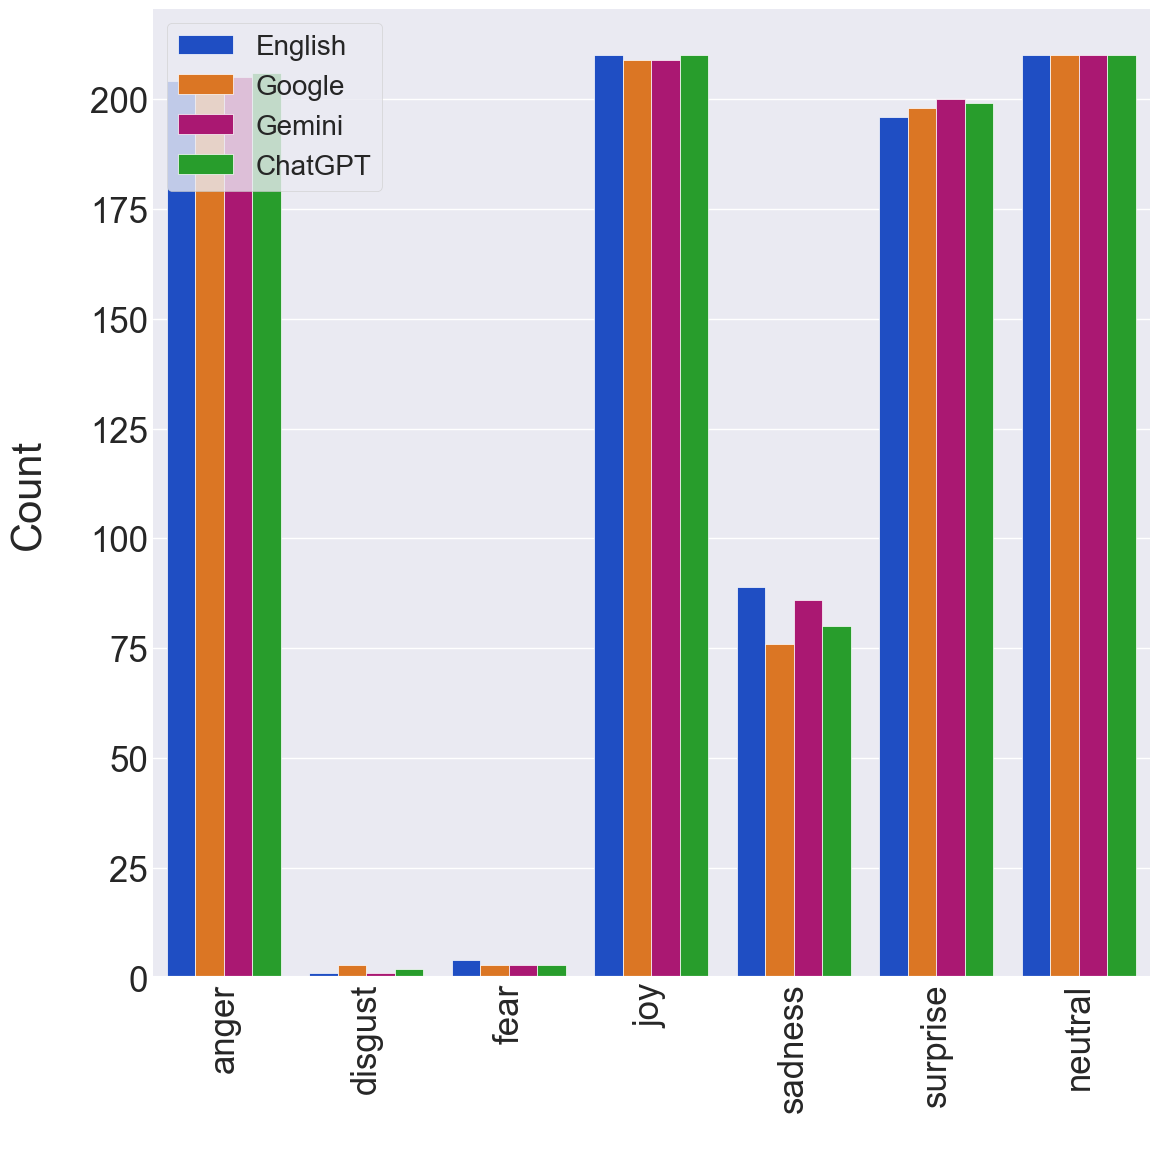

In [297]:
import seaborn as sns
import matplotlib.pyplot as plt
def sentiment_bar(OUTPUT_BASE, SAVEFIG, locate):
    output_base = OUTPUT_BASE
    output_graphs = os.path.join(output_base, 'graphs')
    os.makedirs(output_graphs, exist_ok = True)
    
    en_sentiment = all_article_dataframe('en/', ekman_classes, OUTPUT_BASE)
    ggl_sentiment = all_article_dataframe('ggl/', ekman_classes, OUTPUT_BASE)
    gem_sentiment = all_article_dataframe('gem/', ekman_classes, OUTPUT_BASE)
    gpt_sentiment = all_article_dataframe('gpt/', ekman_classes, OUTPUT_BASE)
    
    df_new = pd.concat(
        [
            en_sentiment, 
            ggl_sentiment['Count'], 
            gem_sentiment['Count'], 
            gpt_sentiment['Count'],
        ],
        axis=1
    )
    
    print(df_new)
    
    df_new.columns = ['Sentiment', 'English', 'Google', 'Gemini', 'ChatGPT']
    print(df_new)
    
    df_sentiment_counts = df_new.T.reset_index()
    df_sentiment_counts.columns = df_sentiment_counts.iloc[0, ]
    df_sentiment_counts = df_sentiment_counts.iloc[1:, ].reset_index(drop=True)
    df_sentiment_counts = df_sentiment_counts.rename(columns={'Sentiment': 'Models'})
    
    print(df_sentiment_counts.head())
    print(df_sentiment_counts.columns)
    
    df_new = pd.melt(df_new, id_vars="Sentiment", var_name="Models", value_name="Count")
    print(df_new)
    colors = ["blue", "orange", "magenta", "green"]  
    myPalette = sns.xkcd_palette(colors)
    
    sns.set_style("darkgrid")
    g = sns.catplot(x='Sentiment', y='Count', hue='Models', data=df_new, kind='bar', height=12, palette=myPalette, legend=True, legend_out = False)
    g.despine(left=True)
    ax = g.ax

    sns.move_legend(
        ax,
        loc = locate,
        title = None,
        frameon = True,
        prop = {"size": 20}
    )
    
    ax.set_ylabel('Count', labelpad=30, fontsize=30)
    ax.set_xlabel(' ')
    #plt.gca().yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}')) #{tick values, add commas for thousands operator, round to 0 decimal places}
    ax.tick_params(axis = "y", labelsize= 25)
    ax.tick_params(axis = "x", labelsize= 25, rotation=90)

    plt.tight_layout()    
    plt.savefig(SAVEFIG, bbox_inches='tight')

sentiment_bar('results/ge_news/sentiment/', 'results/ge_news/sentiment/graphs/sentiment_all_bar.png', 'upper left')

In [328]:
from textblob import TextBlob

df_orig = combine_news(texts_path + "orig/ge_original_1tv_news/combined_all_articles_ge.csv", texts_path + "orig/ge_original_IPN_news/IPN_news_combined_master_ge_renamed.csv")
df_orig.to_csv("Data/Georgian/GeorgianNews/orig/combined_all_articles_ge.csv", index = False)

df_en = combine_news(texts_path + "en/eng_expert_1tv_news/combined_all_articles_eng.csv", texts_path + "en/eng_expert_IPN_news/IPN_news_combined_master_eng_renamed.csv")
df_en.to_csv("Data/Georgian/GeorgianNews/en/combined_all_articles_eng.csv", index = False)

df_gem = combine_news(texts_path + "gem/gem_1tv_news/combined_all_articles_gem.csv", texts_path + "gem/gem_IPN_news/IPN_news_combined_master_gem_renamed.csv")
df_gem.to_csv("Data/Georgian/GeorgianNews/gem/combined_all_articles_gem.csv", index = False)

df_ggl = combine_news(texts_path + "ggl/ggl_1tv_news/combined_all_articles_ggl.csv", texts_path + "ggl/ggl_IPN_news/IPN_news_combined_master_ggl_renamed.csv")
df_ggl.to_csv("Data/Georgian/GeorgianNews/ggl/combined_all_articles_ggl.csv", index = False)

df_gpt = combine_news(texts_path + "gpt/gpt_1tv_news/combined_all_articles_gpt.csv", texts_path + "gpt/gpt_IPN_news/IPN_news_combined_master_gpt_renamed.csv")
df_gpt.to_csv("Data/Georgian/GeorgianNews/gpt/combined_all_articles_gpt.csv", index = False)


file_paths = [
    'Data/Georgian/GeorgianNews/en/combined_all_articles_eng.csv',
    'Data/Georgian/GeorgianNews/ggl/combined_all_articles_ggl.csv',
    'Data/Georgian/GeorgianNews/gem/combined_all_articles_gem.csv',
    'Data/Georgian/GeorgianNews/gpt/combined_all_articles_gpt.csv',
]

labels = ['Human Expert', 'Google Translate', 'Gemini', 'GPT-5.4-mini']

output_path = 'results/ge_news/sentiment/graphs/polarity.png'

def plot_textblob_polarity(file_paths, labels, output_path, NUM_TO_AVG, TICK_INTERVAL):
    plt.figure(figsize=(12, 6))
    for file_path, label in zip(file_paths, labels):
        df = pd.read_csv(file_path)
        if "Translated Content" in df.columns:
            text_column = df["Translated Content"]
        elif "Content" in df.columns:
            text_column = df["Content"]
        elif "text" in df.columns:
            text_column = df["text"]

        text_column = text_column.dropna().astype(str)
        text_column = text_column[text_column.str.strip() != ""]
        
        polarity_scores = [TextBlob(text).sentiment.polarity for text in text_column]
        avg_polarity_scores = []
        x_axis_labels = []
        for i in range(0, len(polarity_scores), NUM_TO_AVG):
            chunk = polarity_scores[i:i + NUM_TO_AVG]
            avg_polarity = np.mean(chunk) if chunk else 0
            avg_polarity_scores.append(avg_polarity)
            x_axis_labels.append(i + NUM_TO_AVG)
        plt.plot(x_axis_labels, avg_polarity_scores, label=label)
    plt.xlabel('Paragraph Count', fontsize=18)
    plt.ylabel('Average Sentiment Polarity Score', fontsize=18)

    max_x = max(x_axis_labels)
    plt.xticks(ticks=range(0, max_x + 1, TICK_INTERVAL), fontsize=12)
    plt.yticks(fontsize=12)

    plt.legend(
        title="Models",
        fontsize=12,
        title_fontsize=13,
        loc="best",
        frameon=True
    )

    ax = plt.gca()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_visible(False)

    plt.grid(True)
    plt.tight_layout()
    plt.savefig(output_path, format="png", bbox_inches="tight", dpi=300)
    plt.show()

plot_textblob_polarity(file_paths, labels, output_path, 5, 10)

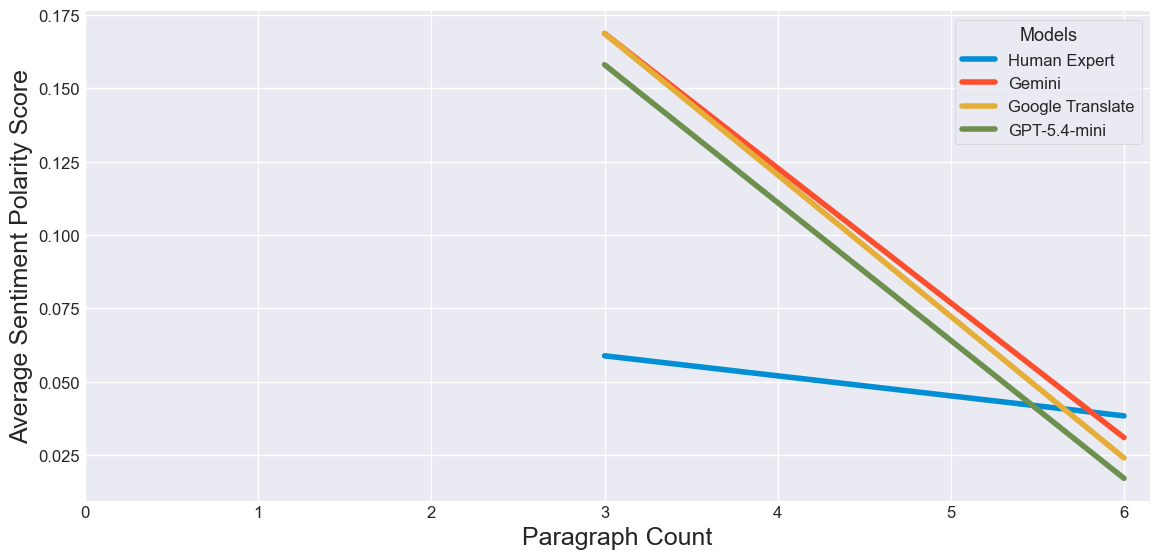

In [299]:
sentiment_files = [
    'results/ge_news/sentiment/en/01_deputy_economy_minister.csv',
    'results/ge_news/sentiment/gem/01_deputy_economy_minister.csv',
    'results/ge_news/sentiment/ggl/01_deputy_economy_minister.csv',
    'results/ge_news/sentiment/gpt/01_deputy_economy_minister.csv',
]

labels = ['Human Expert', 'Gemini', 'Google Translate', 'GPT-5.4-mini']

output_path = 'results/ge_news/sentiment/graphs/polarity_01_deputy_economy_minister.png'

plot_textblob_polarity(sentiment_files, labels, output_path, 3, 1)

In [300]:
%matplotlib inline
sns.set_style("whitegrid")
plt.style.use("fivethirtyeight")

In [301]:
import re
import gensim 
import nltk
from nltk.corpus import stopwords

stop_words = stopwords.words('english')
newStopWords = []
stop_words.extend(newStopWords)


def remove_stopwords(texts):
    return [[word for word in gensim.utils.simple_preprocess(str(text)) if word not in stop_words] for text in texts]
    #list without stopwords

def tokenize(texts):
    for text in texts:
        yield(gensim.utils.simple_preprocess(str(text), deacc=True))
        #tokenized, without punctuation, accents

def preprocessing(df):
    df = df.copy()
    df['text'] = df['text'].str.lower()                                                      # Convert to lowercase
    df['text'] = df['text'].str.replace(r'[^a-zA-Z#]', ' ', regex=True) #     # keep letters and spaces only
    df['text'] = df['text'].apply(lambda x:' '.join([w for w in x.split() if len(w)>2]))     # Remove short words
    df['tokens'] = list(tokenize(df['text']))
    df['tokens_no_stop'] = remove_stopwords(df['text'])
    df['tokens_no_stop_joined'] = df['tokens_no_stop'].apply(lambda x: ' '.join(x) )
    
    return df

def retrieve_text(df):
    doc = '. '.join(df['tokens_no_stop_joined'])
    return doc

def ngrams_series_func(data, n):
    wordList = re.sub("[^\w]", " ",  data).split() #replace non-words with spaces
    ngrams_series = (pd.Series(nltk.ngrams(wordList, n)).value_counts())[:5] #top 5 most frequent
    return ngrams_series

In [302]:
from matplotlib import cm
from matplotlib.ticker import FuncFormatter

cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)
barcolors = ['#87B88C','#9ED2A1','#E7E8CB','#48A0C9','#2A58A1','#2E8B55','#DF3659','Grey']
barstyle = {"edgecolor":"black", "linewidth": 1}

In [303]:
def topic(source, OUTPUT_BASE, article_names):
    topic_df = pd.read_csv(OUTPUT_BASE + source + article_names[0])

    #print(topic_df)
    
    for article in article_names[1:]:
        df = pd.read_csv(OUTPUT_BASE + source + article) #'results_bul/news/sentiment/'
        topic_df = pd.concat([topic_df, df], axis=0, ignore_index=True)
    
    return topic_df

In [304]:
from matplotlib.ticker import MaxNLocator

def ngrams_graphs(text, translation, OUTPUT_BASE):  
    output_ngrams = os.path.join(output_graphs, 'ngrams')
    os.makedirs(output_ngrams, exist_ok = True)
    
    bigram1 = ngrams_series_func(text, 2)
    trigram1 = ngrams_series_func(text, 3)
    ngram1 = pd.concat([bigram1, trigram1])
    
    plt.rcParams.update({'font.size': 20})
    fig, ax=plt.subplots(1,1, figsize=(8,4))
    
    barh_ax = ax
    
    ngram1[::-1].plot.barh(ax=barh_ax, color='magenta', **barstyle)
    barh_ax.yaxis.set_label_position("left")
    barh_ax.xaxis.tick_top()
    barh_ax.xaxis.set_label_position("bottom")
    barh_ax.set_xlim(barh_ax.get_xlim()[::-1])
    barh_ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    barh_ax.set_xlabel(translation)
    barh_ax.set_ylabel('', fontsize=50)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_BASE}graphs/ngrams/{translation}.png', facecolor='white')


0
Empty DataFrame
Columns: [text, anger, disgust, fear, joy, sadness, surprise, neutral]
Index: []


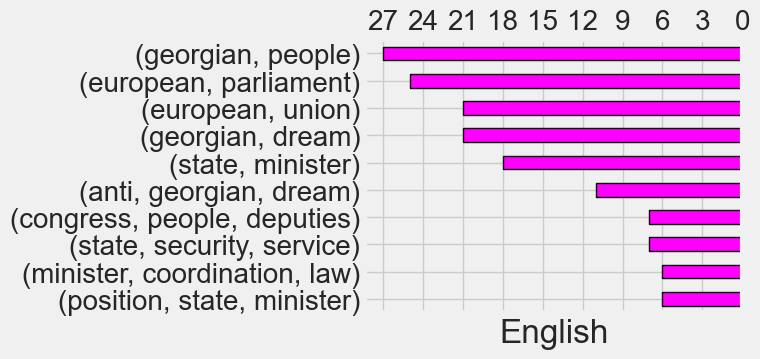

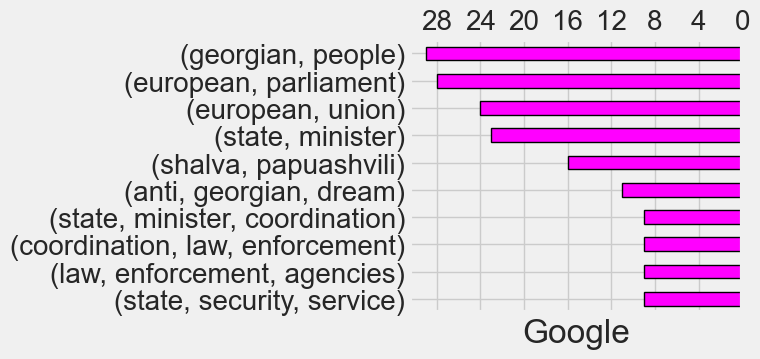

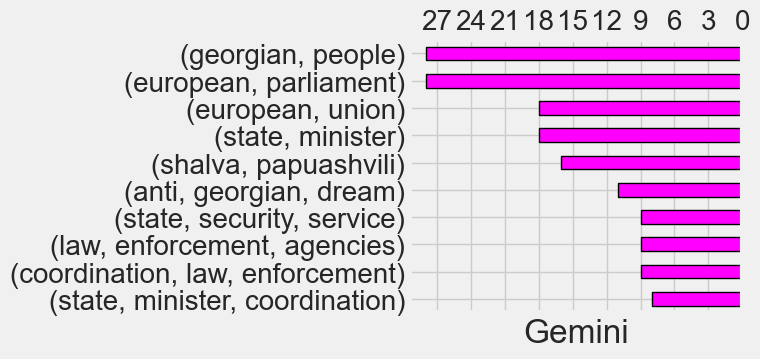

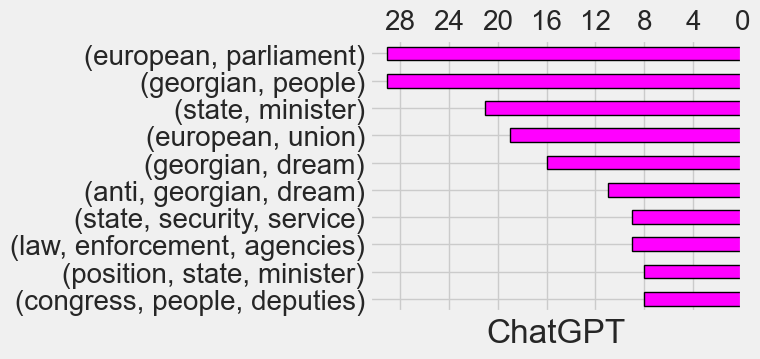

In [305]:
#Georgian News
OUTPUT_BASE = "results/ge_news/sentiment/"
topic_df = topic('en/', OUTPUT_BASE, article_names)
print(topic_df["text"].isna().sum())
print(topic_df[topic_df["text"].isna()].head(20))

topic_df = preprocessing(topic_df)
topic_df.head()
text = retrieve_text(topic_df)
text.split('. ')

ngrams_graphs(text, 'English', OUTPUT_BASE)

topic_df = topic('ggl/', OUTPUT_BASE, article_names)
topic_df = preprocessing(topic_df)
topic_df.head()
text = retrieve_text(topic_df)
text.split('. ')

ngrams_graphs(text, 'Google', OUTPUT_BASE)

topic_df = topic('gem/', OUTPUT_BASE, article_names)
topic_df = preprocessing(topic_df)
topic_df.head()
text = retrieve_text(topic_df)
text.split('. ')

ngrams_graphs(text, 'Gemini', OUTPUT_BASE)

topic_df = topic('gpt/', OUTPUT_BASE, article_names)
topic_df = preprocessing(topic_df)
topic_df.head()
text = retrieve_text(topic_df)
text.split('. ')

ngrams_graphs(text, 'ChatGPT', OUTPUT_BASE)

In [306]:
file_paths = [
    'Data/Georgian/GeorgianNews/en/combined_all_articles_eng.csv',
    'Data/Georgian/GeorgianNews/ggl/combined_all_articles_ggl.csv',
    'Data/Georgian/GeorgianNews/gem/combined_all_articles_gem.csv',
    'Data/Georgian/GeorgianNews/gpt/combined_all_articles_gpt.csv',
]

labels = ['Human Expert', 'Google Translate', 'Gemini', 'GPT-5.4-mini']

output_path = 'results/ge_news/sentiment/graphs/polarity.png'

plot_textblob_polarity(file_paths, labels, output_path, 5, 10)

In [ ]:
sentiment_files = [
    'results/ge_news/sentiment/en/01_deputy_economy_minister.csv',
    'results/ge_news/sentiment/gem/01_deputy_economy_minister.csv',
    'results/ge_news/sentiment/ggl/01_deputy_economy_minister.csv',
    'results/ge_news/sentiment/gpt/01_deputy_economy_minister.csv',
]

labels = ['Human Expert', 'Gemini', 'Google Translate', 'GPT-5.4-mini']

output_path = 'results/ge_news/sentiment/graphs/polarity_01_deputy_economy_minister.png'

plot_textblob_polarity(sentiment_files, labels, output_path, 3, 1)

In [307]:
#Bulgarian News

texts_path = 'Data/Bulgarian/BulgarianNews/'
#ge_1tv_csv = texts_path + "ge/ge_original_1tv_news/combined_all_articles_ge.csv"
#ge_IPN_csv = texts_path + "ge/ge_original_IPN_news/IPN_news_combined_master_ge_renamed.csv"

#df_1tv_ge = pd.read_csv(ge_1tv_csv)
#df_IPN_ge = pd.read_csv(ge_IPN_csv)

#df_ge = pd.concat([df_1tv_ge, df_IPN_ge], axis = 0)
#print(df_ge.head())
#print(df_ge.columns)

In [308]:
file_paths = ["orig/BTA_news_combined_master_bul.csv", 
              "en/BTA_news_combined_master_eng.csv",
              "gem/BTA_news_combined_master_gem.csv",
              "ggl/BTA_news_combined_master_ggl.csv",
              "gpt/BTA_news_combined_master_gpt.csv"]

OUTPUT_BASE = 'results/bul_news/sentiment/'

def text_name(texts_path, file_paths):
    sources = ['orig/', 'en/', 'ggl/', 'gem/', 'gpt/']
    df_orig = pd.read_csv(texts_path + file_paths[0])
    df_en = pd.read_csv(texts_path + file_paths[1])
    df_gem = pd.read_csv(texts_path + file_paths[2])
    df_ggl = pd.read_csv(texts_path + file_paths[3])
    df_gpt = pd.read_csv(texts_path + file_paths[4])
    article_names = sorted(df_orig["Source File"].unique())
    print(article_names)
    print(len(article_names))
    return article_names, df_orig, df_en, df_ggl, df_gem, df_gpt

article_names, df_orig, df_en, df_ggl, df_gem, df_gpt = text_name(texts_path, file_paths)
text_df(OUTPUT_BASE, article_names, df_orig, df_en, df_ggl, df_gem, df_gpt)


['01_bul_Political_Forces.csv', '02_bul_Bulgarian_Airline.csv', '03_bul_Bulgarian_Cultural.csv', '04_bul_Bulgaria_Driving.csv', '05_bul_Bulgarian_Deputy.csv', '06_bul_Patriarch_Daniil.csv', '07_bul_Mexico_Festival.csv', '08_bul_Bulgaria_Submits.csv', '09_bul_Dispute_Erupts.csv']
9
Saved: results/bul_news/sentiment/orig/01_bul_Political_Forces.csv
Saved: results/bul_news/sentiment/orig/02_bul_Bulgarian_Airline.csv
Saved: results/bul_news/sentiment/orig/03_bul_Bulgarian_Cultural.csv
Saved: results/bul_news/sentiment/orig/04_bul_Bulgaria_Driving.csv
Saved: results/bul_news/sentiment/orig/05_bul_Bulgarian_Deputy.csv
Saved: results/bul_news/sentiment/orig/06_bul_Patriarch_Daniil.csv
Saved: results/bul_news/sentiment/orig/07_bul_Mexico_Festival.csv
Saved: results/bul_news/sentiment/orig/08_bul_Bulgaria_Submits.csv
Saved: results/bul_news/sentiment/orig/09_bul_Dispute_Erupts.csv
Saved: results/bul_news/sentiment/en/01_bul_Political_Forces.csv
Saved: results/bul_news/sentiment/en/02_bul_Bulgar

  Sentiment  Count  Count  Count  Count
0     anger     81     81     81     81
1   disgust      0      0      0      0
2      fear      0      1      1      1
3       joy     81     82     82     82
4   sadness     17     19     19     19
5  surprise     82     81     81     81
6   neutral     82     82     82     82
  Sentiment  English  Google  Gemini  ChatGPT
0     anger       81      81      81       81
1   disgust        0       0       0        0
2      fear        0       1       1        1
3       joy       81      82      82       82
4   sadness       17      19      19       19
5  surprise       82      81      81       81
6   neutral       82      82      82       82
0   Models anger disgust fear joy sadness surprise neutral
0  English    81       0    0  81      17       82      82
1   Google    81       0    1  82      19       81      82
2   Gemini    81       0    1  82      19       81      82
3  ChatGPT    81       0    1  82      19       81      82
Index(['Models', 

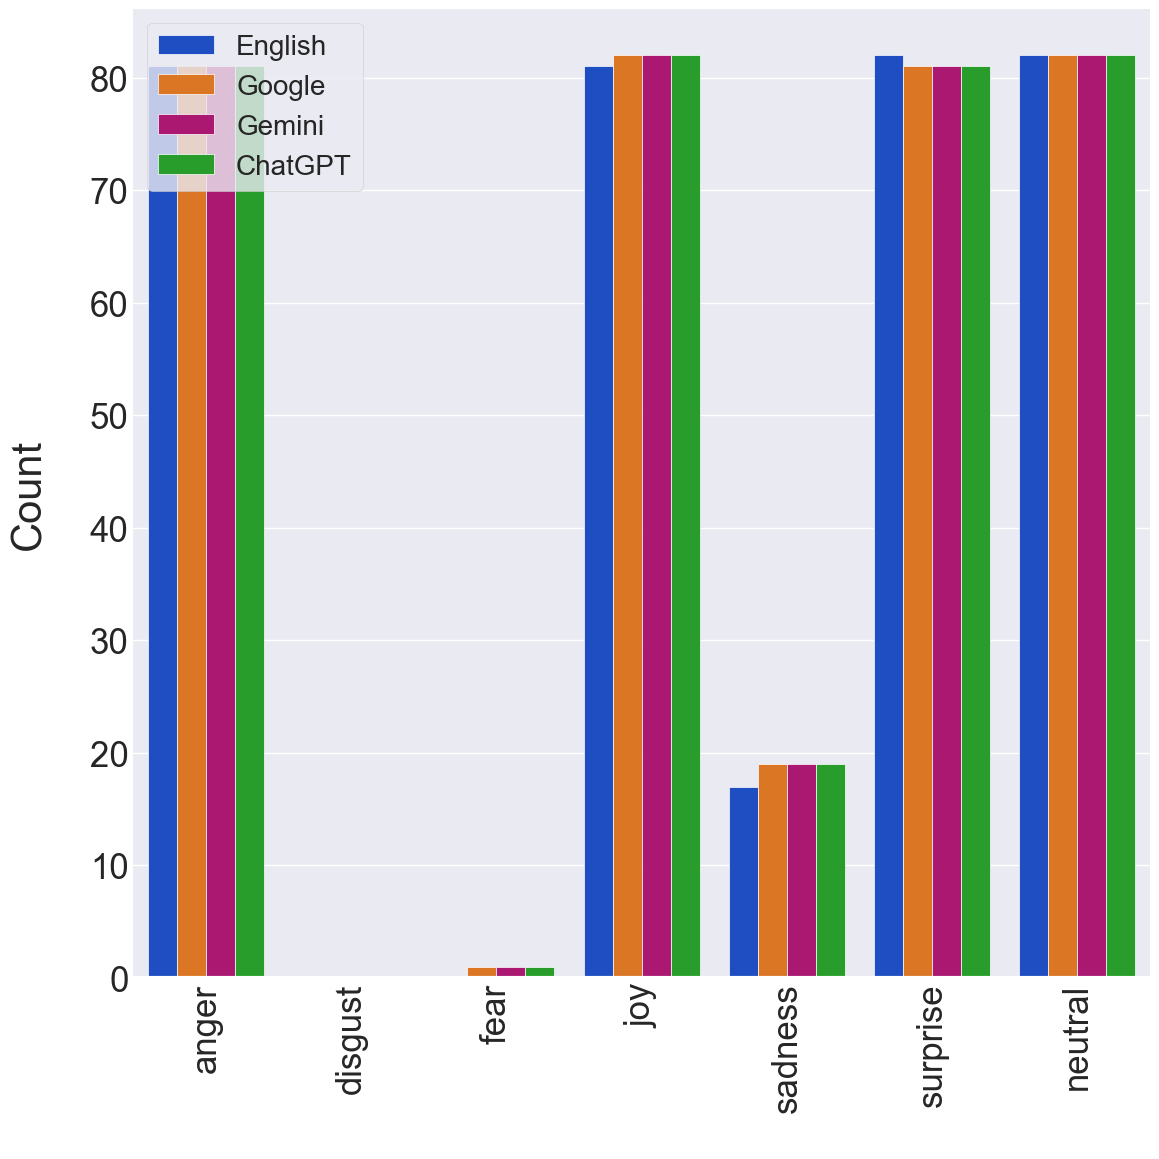

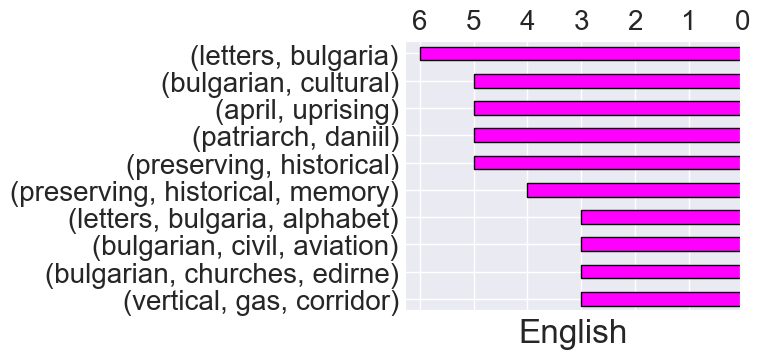

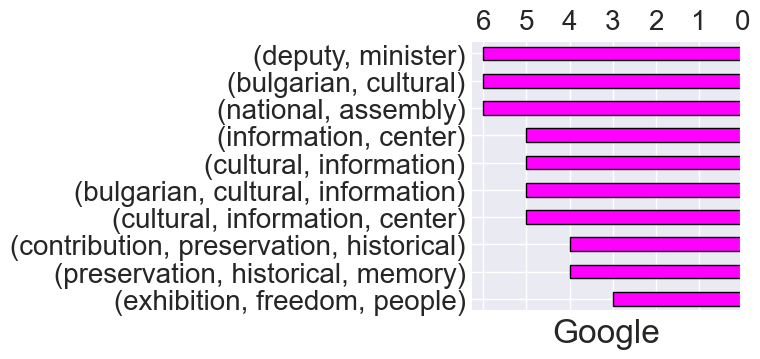

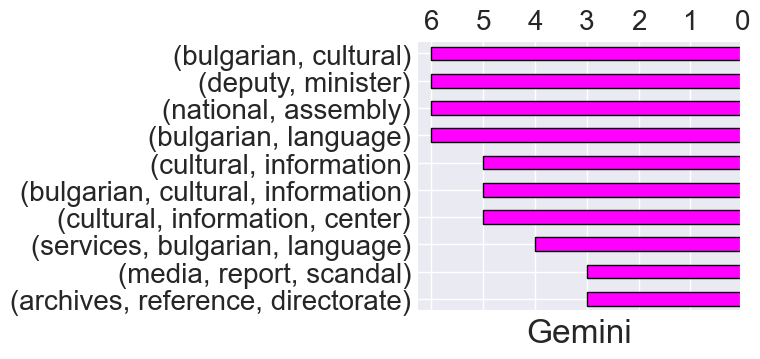

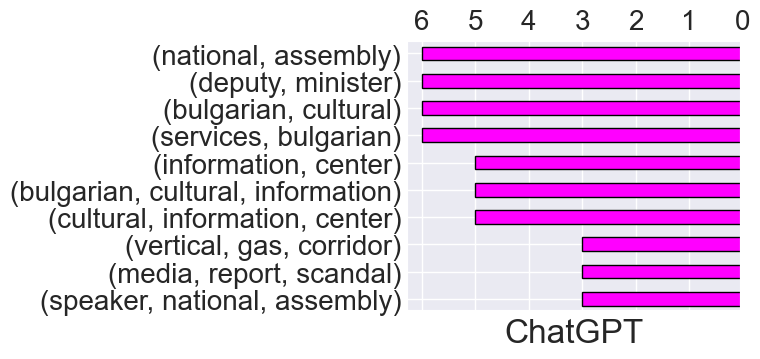

In [309]:
sentiment_bar(OUTPUT_BASE, 'results/bul_news/sentiment/graphs/sentiment_all_bar.png', 'upper left')

topic_df = topic('en/', OUTPUT_BASE, article_names) 
topic_df = preprocessing(topic_df)
topic_df.head()
text = retrieve_text(topic_df)
text.split('. ')

output_graphs = os.path.join(OUTPUT_BASE, 'graphs')
os.makedirs(output_graphs, exist_ok = True)
    
ngrams_graphs(text, 'English', OUTPUT_BASE)

topic_df = topic('ggl/', OUTPUT_BASE, article_names)
topic_df = preprocessing(topic_df)
topic_df.head()
text = retrieve_text(topic_df)
text.split('. ')

ngrams_graphs(text, 'Google', OUTPUT_BASE)

topic_df = topic('gem/', OUTPUT_BASE, article_names)
topic_df = preprocessing(topic_df)
topic_df.head()
text = retrieve_text(topic_df)
text.split('. ')

ngrams_graphs(text, 'Gemini', OUTPUT_BASE)

topic_df = topic('gpt/', OUTPUT_BASE, article_names)
topic_df = preprocessing(topic_df)
topic_df.head()
text = retrieve_text(topic_df)
text.split('. ')

ngrams_graphs(text, 'ChatGPT', OUTPUT_BASE)

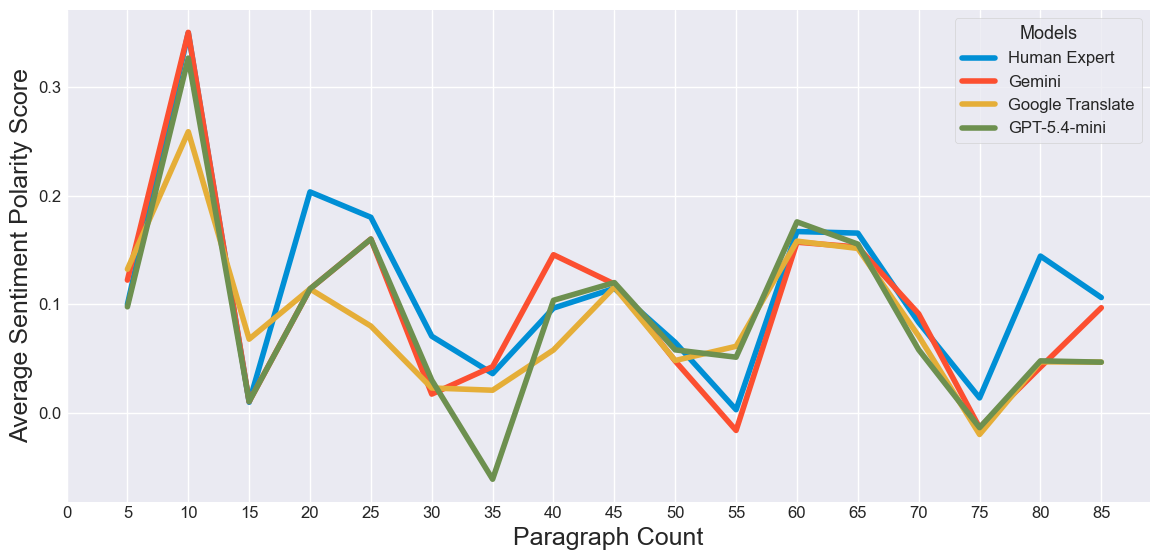

In [312]:
file_paths = [
    'Data/Bulgarian/BulgarianNews/en/BTA_news_combined_master_eng.csv',
    'Data/Bulgarian/BulgarianNews/gem/BTA_news_combined_master_gem.csv',
    'Data/Bulgarian/BulgarianNews/ggl/BTA_news_combined_master_ggl.csv',
    'Data/Bulgarian/BulgarianNews/gpt/BTA_news_combined_master_gpt.csv',
]

labels = ['Human Expert', 'Gemini', 'Google Translate','GPT-5.4-mini']

output_path = 'results/bul_news/sentiment/graphs/polarity.png'
plot_textblob_polarity(file_paths, labels, output_path, 5, 5)

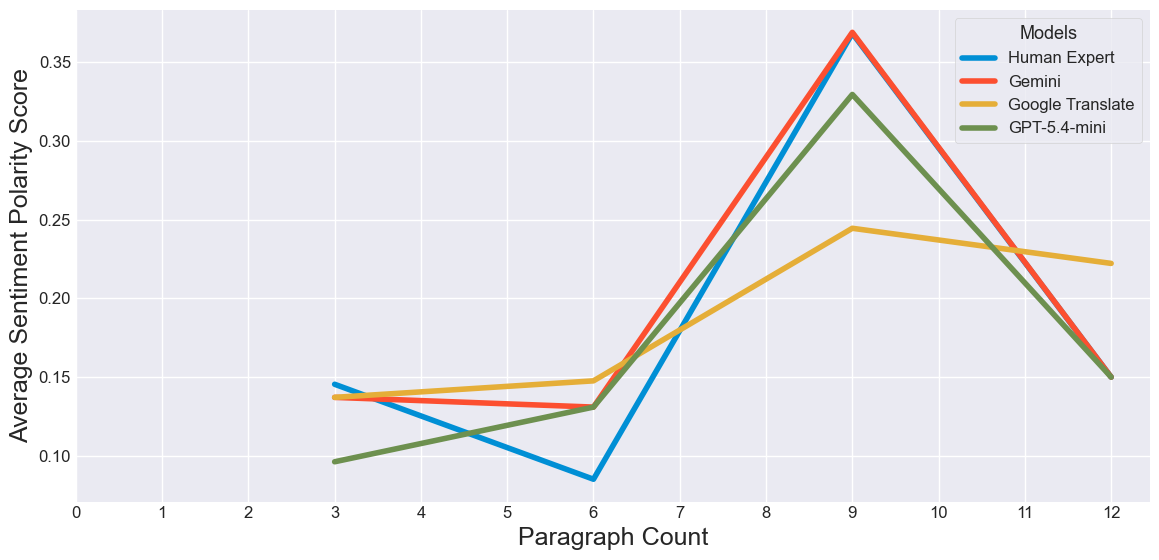

In [313]:
sentiment_files = [
    'results/bul_news/sentiment/en/01_bul_Political_Forces.csv',
    'results/bul_news/sentiment/gem/01_bul_Political_Forces.csv',
    'results/bul_news/sentiment/ggl/01_bul_Political_Forces.csv',
    'results/bul_news/sentiment/gpt/01_bul_Political_Forces.csv',
]

labels = ['Human Expert', 'Gemini', 'Google Translate', 'GPT-5.4-mini']

output_path = 'results/bul_news/sentiment/graphs/polarity_01_bul_Political_Forces.png'

plot_textblob_polarity(sentiment_files, labels, output_path, 3, 1)

In [314]:
#Georgian poems

texts_path = 'Data/Georgian/Vazha_ThreePoems/'

In [315]:
file_paths = ["orig/combined_vazha_poems_ge.csv", 
              "en/combined_vazha_poems_en.csv",
              "gem/combined_vazha_poems_gem.csv",
              "ggl/combined_vazha_poems_ggl.csv",
              "gpt/combined_vazha_poems_gpt.csv"]

OUTPUT_BASE = 'results/ge_poems/sentiment/'

article_names, df_orig, df_en, df_ggl, df_gem, df_gpt = text_name(texts_path, file_paths)
text_df(OUTPUT_BASE, article_names, df_orig, df_en, df_ggl, df_gem, df_gpt)

['01_aluda_ketelauri_ge.csv', '02_host_and_guest_ge.csv', '03_the_snake_eater_ge.csv']
3
Saved: results/ge_poems/sentiment/orig/01_aluda_ketelauri_ge.csv
Saved: results/ge_poems/sentiment/orig/02_host_and_guest_ge.csv
Saved: results/ge_poems/sentiment/orig/03_the_snake_eater_ge.csv
Saved: results/ge_poems/sentiment/en/01_aluda_ketelauri_ge.csv
Saved: results/ge_poems/sentiment/en/02_host_and_guest_ge.csv
Saved: results/ge_poems/sentiment/en/03_the_snake_eater_ge.csv
Saved: results/ge_poems/sentiment/ggl/01_aluda_ketelauri_ge.csv
Saved: results/ge_poems/sentiment/ggl/02_host_and_guest_ge.csv
Saved: results/ge_poems/sentiment/ggl/03_the_snake_eater_ge.csv
Saved: results/ge_poems/sentiment/gem/01_aluda_ketelauri_ge.csv
Saved: results/ge_poems/sentiment/gem/02_host_and_guest_ge.csv
Saved: results/ge_poems/sentiment/gem/03_the_snake_eater_ge.csv
Saved: results/ge_poems/sentiment/gpt/01_aluda_ketelauri_ge.csv
Saved: results/ge_poems/sentiment/gpt/02_host_and_guest_ge.csv
Saved: results/ge_po

  Sentiment  Count  Count  Count  Count
0     anger    223    221    220    222
1   disgust      4      3      2      5
2      fear     26     22     22     21
3       joy    221    224    221    224
4   sadness    142    142    136    152
5  surprise    141    156    145    143
6   neutral    240    238    239    239
  Sentiment  English  Google  Gemini  ChatGPT
0     anger      223     221     220      222
1   disgust        4       3       2        5
2      fear       26      22      22       21
3       joy      221     224     221      224
4   sadness      142     142     136      152
5  surprise      141     156     145      143
6   neutral      240     238     239      239
0   Models anger disgust fear  joy sadness surprise neutral
0  English   223       4   26  221     142      141     240
1   Google   221       3   22  224     142      156     238
2   Gemini   220       2   22  221     136      145     239
3  ChatGPT   222       5   21  224     152      143     239
Index(['Mode

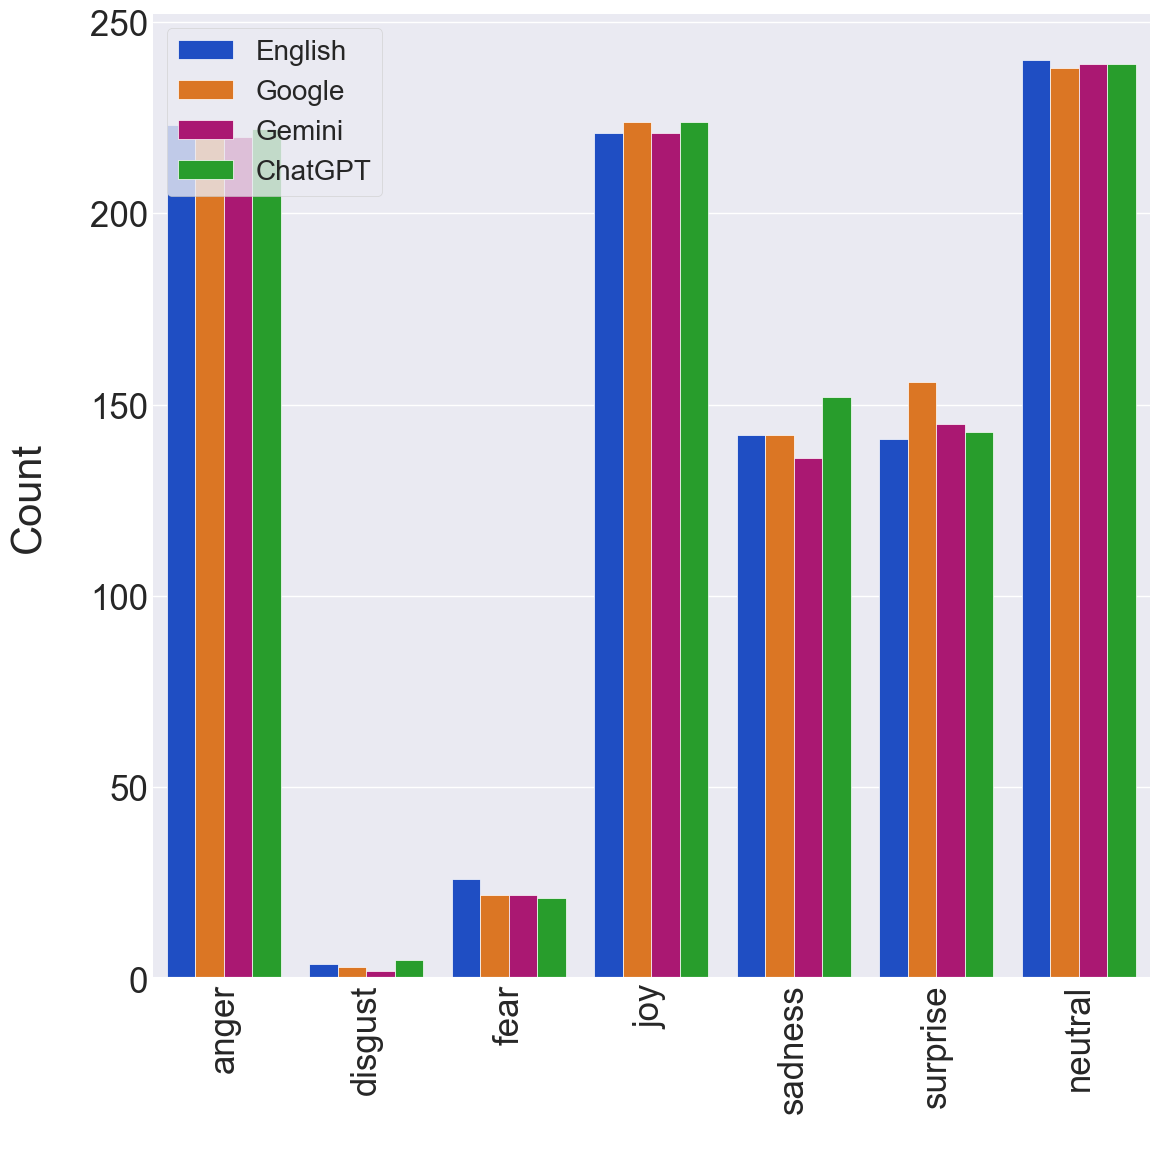

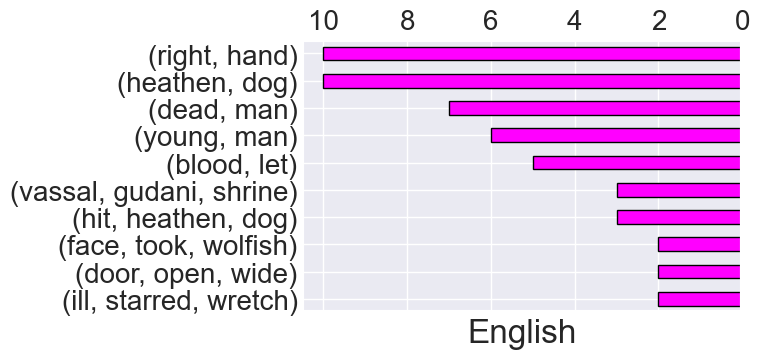

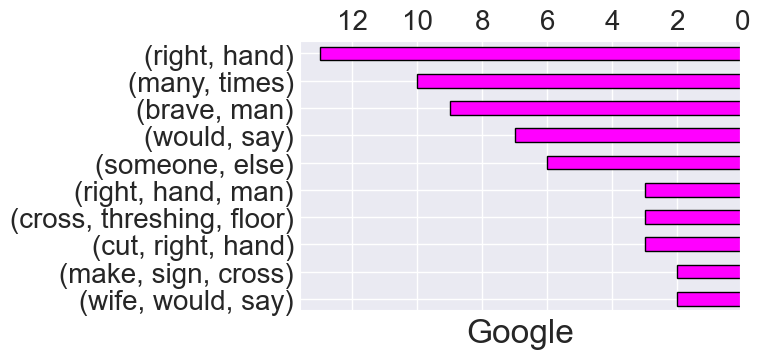

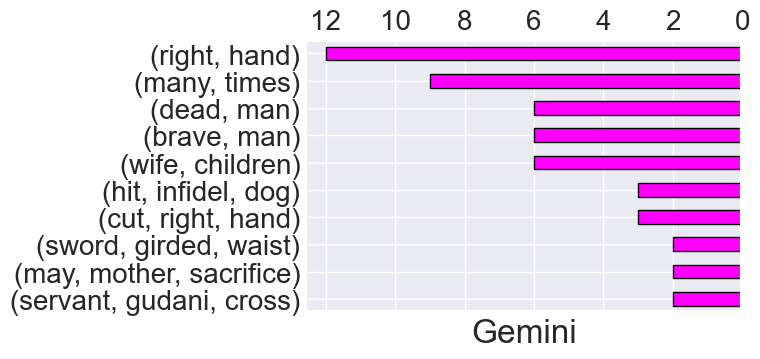

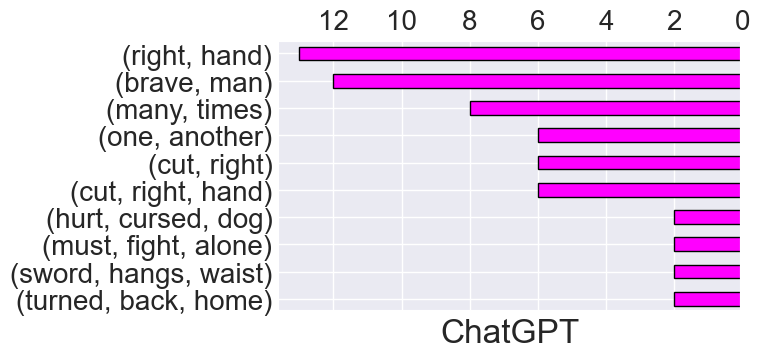

In [316]:
sentiment_bar(OUTPUT_BASE, 'results/ge_poems/sentiment/graphs/sentiment_all_bar.png', 'upper left')

topic_df = topic('en/', OUTPUT_BASE, article_names) 
topic_df = preprocessing(topic_df)
topic_df.head()
text = retrieve_text(topic_df)
text.split('. ')

output_graphs = os.path.join(OUTPUT_BASE, 'graphs')
os.makedirs(output_graphs, exist_ok = True)
    
ngrams_graphs(text, 'English', OUTPUT_BASE)

topic_df = topic('ggl/', OUTPUT_BASE, article_names)
topic_df = preprocessing(topic_df)
topic_df.head()
text = retrieve_text(topic_df)
text.split('. ')

ngrams_graphs(text, 'Google', OUTPUT_BASE)

topic_df = topic('gem/', OUTPUT_BASE, article_names)
topic_df = preprocessing(topic_df)
topic_df.head()
text = retrieve_text(topic_df)
text.split('. ')

ngrams_graphs(text, 'Gemini', OUTPUT_BASE)

topic_df = topic('gpt/', OUTPUT_BASE, article_names)
topic_df = preprocessing(topic_df)
topic_df.head()
text = retrieve_text(topic_df)
text.split('. ')

ngrams_graphs(text, 'ChatGPT', OUTPUT_BASE)

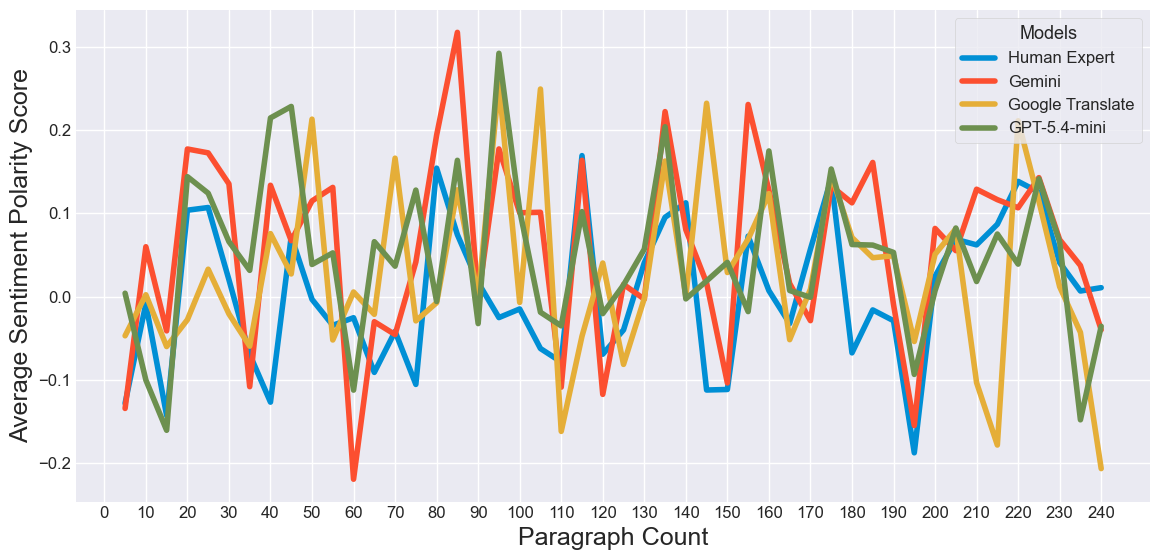

In [318]:
file_paths = [
    'Data/Georgian/Vazha_ThreePoems/en/combined_vazha_poems_en.csv',
    'Data/Georgian/Vazha_ThreePoems/gem/combined_vazha_poems_gem.csv',
    'Data/Georgian/Vazha_ThreePoems/ggl/combined_vazha_poems_ggl.csv',
    'Data/Georgian/Vazha_ThreePoems/gpt/combined_vazha_poems_gpt.csv',
]

labels = ['Human Expert', 'Gemini', 'Google Translate','GPT-5.4-mini']

output_path = 'results/ge_poems/sentiment/graphs/polarity.png'
plot_textblob_polarity(file_paths, labels, output_path, 5, 10)

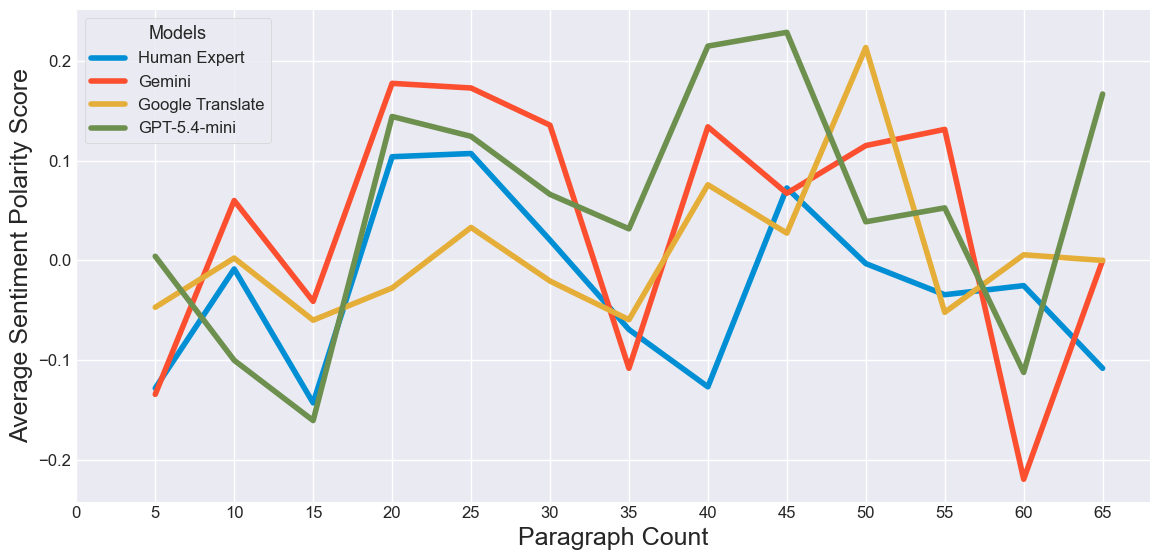

In [323]:
sentiment_files = [
    'results/ge_poems/sentiment/en/01_aluda_ketelauri_ge.csv',
    'results/ge_poems/sentiment/gem/01_aluda_ketelauri_ge.csv',
    'results/ge_poems/sentiment/ggl/01_aluda_ketelauri_ge.csv',
    'results/ge_poems/sentiment/gpt/01_aluda_ketelauri_ge.csv',
]

labels = ['Human Expert', 'Gemini', 'Google Translate', 'GPT-5.4-mini']

output_path = 'results/ge_poems/sentiment/graphs/polarity_01_aluda_ketelauri_ge.png'

plot_textblob_polarity(sentiment_files, labels, output_path, 5, 5)

In [324]:
#Bulgarian prose

texts_path = 'Data/Bulgarian/BaiGanyo/'

In [325]:
file_paths = ["orig/baiganyo_combined_master_bul.csv", 
              "en/baiganyo_combined_master_en.csv",
              "gem/baiganyo_combined_master_gem.csv",
              "ggl/baiganyo_combined_master_ggl.csv",
              "gpt/baiganyo_combined_master_gpt.csv"]

OUTPUT_BASE = 'results/bul_prose/sentiment/'

article_names, df_orig, df_en, df_ggl, df_gem, df_gpt = text_name(texts_path, file_paths)
text_df(OUTPUT_BASE, article_names, df_orig, df_en, df_ggl, df_gem, df_gpt)

['00_bai_ganyo_starts_out_for_europe_bul.csv', '01_bai_ganyo_sets_off_bul.csv', '02_bai_ganyo_at_the_opera_bul.csv', '03_bai_ganyo_at_the_baths_bul.csv', '04_bai_ganyo_in_dresden_bul.csv', '05_bai_ganyo_at_the_prague_exhibition_bul.csv', '06_bai_ganyo_at_jirecheks_bul.csv', '07_bai_ganyo_goes_visiting_bul.csv', '08_bai_ganyo_in_switzerland_bul.csv', '09_bai_ganyo_in_russia_bul.csv', '10_bai_ganyo_returns_from_europe_bul.csv', '11_bai_ganyo_does_elections_bul.csv', '12_bai_ganyo_the_journalist_bul.csv', '13_bai_ganyo_at_the_palace_bul.csv', '14_bai_ganyo_in_the_delegation_bul.csv', '15_bai_ganyo_in_the_opposition_bul.csv', '16_the_temperance_society_bul.csv', '17_letter_from_bai_ganyo_to_konstantin_velichkov_bul.csv', '18_from_the_correspondence_of_bai_ganyo_balkanski_bul.csv']
19
Saved: results/bul_prose/sentiment/orig/00_bai_ganyo_starts_out_for_europe_bul.csv
Saved: results/bul_prose/sentiment/orig/01_bai_ganyo_sets_off_bul.csv
Saved: results/bul_prose/sentiment/orig/02_bai_ganyo_at_

  Sentiment  Count  Count  Count  Count
0     anger    811    813    797    797
1   disgust     14     13      7      5
2      fear     22     29     27     25
3       joy    903    896    883    888
4   sadness    226    260    239    240
5  surprise    800    780    795    804
6   neutral    915    915    908    915
  Sentiment  English  Google  Gemini  ChatGPT
0     anger      811     813     797      797
1   disgust       14      13       7        5
2      fear       22      29      27       25
3       joy      903     896     883      888
4   sadness      226     260     239      240
5  surprise      800     780     795      804
6   neutral      915     915     908      915
0   Models anger disgust fear  joy sadness surprise neutral
0  English   811      14   22  903     226      800     915
1   Google   813      13   29  896     260      780     915
2   Gemini   797       7   27  883     239      795     908
3  ChatGPT   797       5   25  888     240      804     915
Index(['Mode

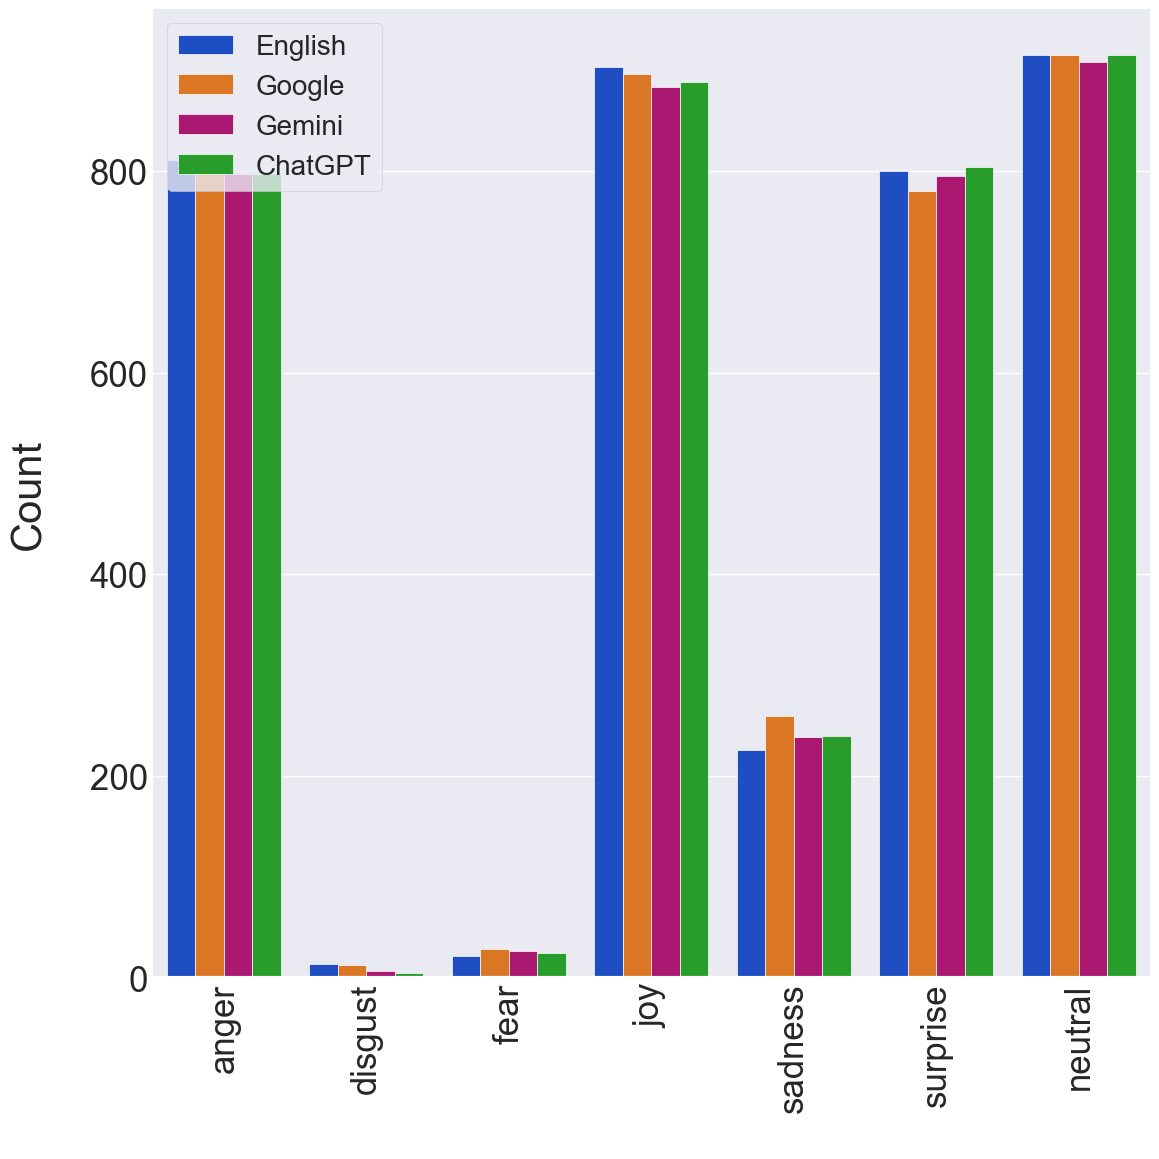

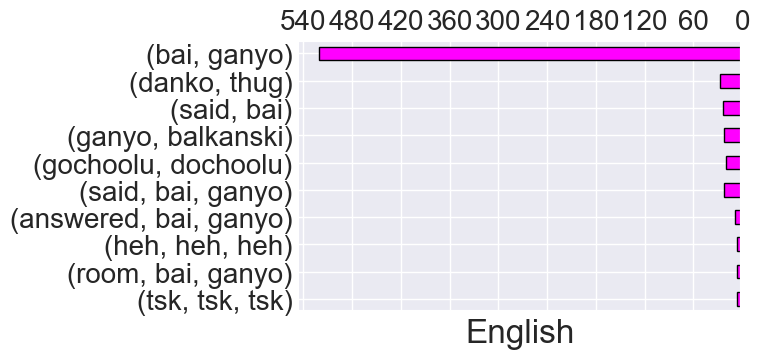

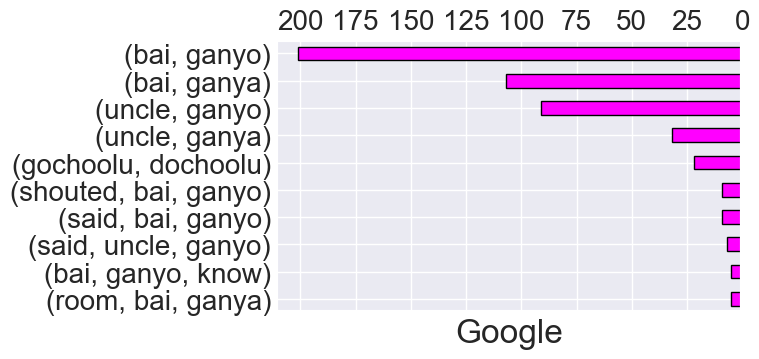

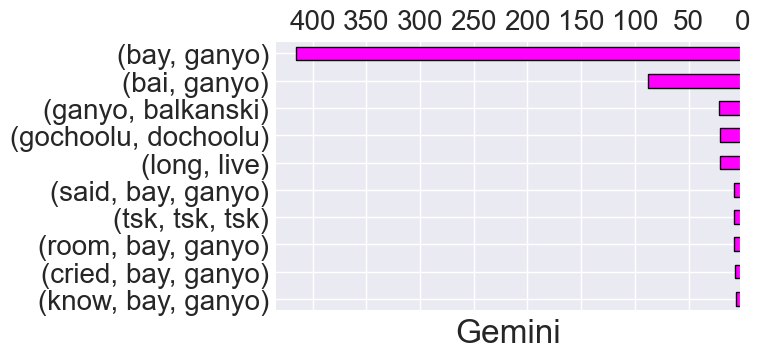

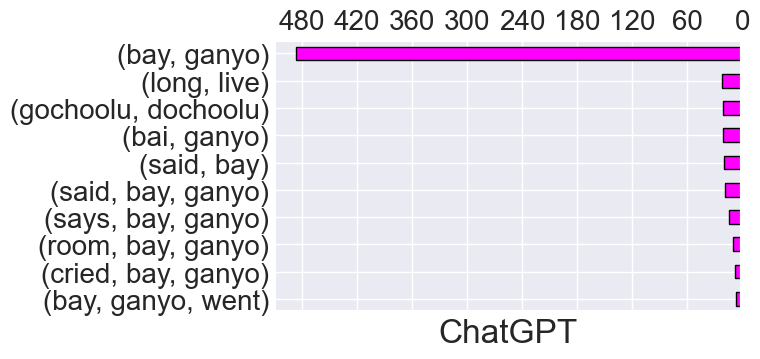

In [326]:
sentiment_bar(OUTPUT_BASE, 'results/bul_prose/sentiment/graphs/sentiment_all_bar.png', 'upper left')

topic_df = topic('en/', OUTPUT_BASE, article_names)
topic_df = preprocessing(topic_df)
topic_df.head()
text = retrieve_text(topic_df)
text.split('. ')

output_graphs = os.path.join(OUTPUT_BASE, 'graphs')
os.makedirs(output_graphs, exist_ok = True)

ngrams_graphs(text, 'English', OUTPUT_BASE)

topic_df = topic('ggl/', OUTPUT_BASE, article_names)
topic_df = preprocessing(topic_df)
topic_df.head()
text = retrieve_text(topic_df)
text.split('. ')

ngrams_graphs(text, 'Google', OUTPUT_BASE)

topic_df = topic('gem/', OUTPUT_BASE, article_names)
topic_df = preprocessing(topic_df)
topic_df.head()
text = retrieve_text(topic_df)
text.split('. ')

ngrams_graphs(text, 'Gemini', OUTPUT_BASE)

topic_df = topic('gpt/', OUTPUT_BASE, article_names)
topic_df = preprocessing(topic_df)
topic_df.head()
text = retrieve_text(topic_df)
text.split('. ')

ngrams_graphs(text, 'ChatGPT', OUTPUT_BASE)

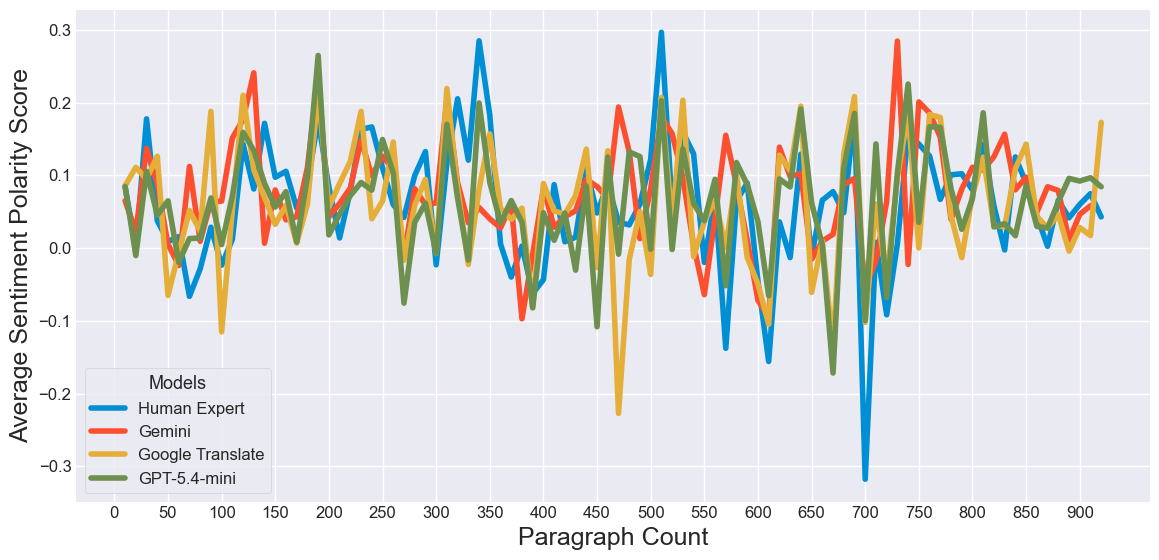

In [330]:
#Gemini was unable to translate some lines

file_paths = [
    'Data/Bulgarian/BaiGanyo/en/baiganyo_combined_master_en.csv',
    'Data/Bulgarian/BaiGanyo/gem/baiganyo_combined_master_gem.csv',
    'Data/Bulgarian/BaiGanyo/ggl/baiganyo_combined_master_ggl.csv',
    'Data/Bulgarian/BaiGanyo/gpt/baiganyo_combined_master_gpt.csv',
]

labels = ['Human Expert', 'Gemini', 'Google Translate','GPT-5.4-mini']

output_path = 'results/bul_prose/sentiment/graphs/polarity.png'
plot_textblob_polarity(file_paths, labels, output_path, 10, 50)

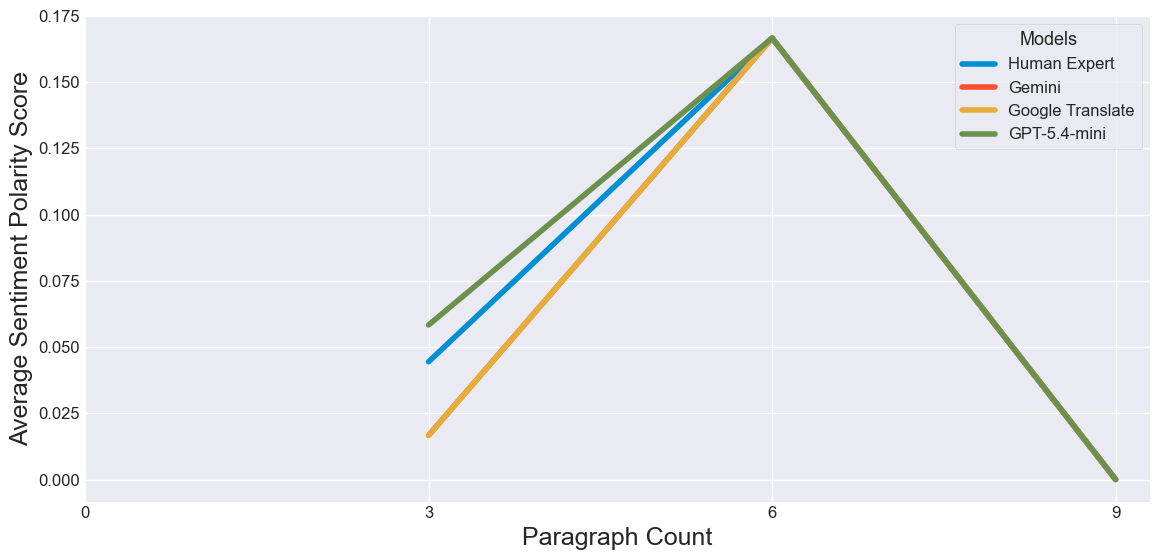

In [335]:
sentiment_files = [
    'results/bul_prose/sentiment/en/00_bai_ganyo_starts_out_for_europe_bul.csv',
    'results/bul_prose/sentiment/gem/00_bai_ganyo_starts_out_for_europe_bul.csv',
    'results/bul_prose/sentiment/ggl/00_bai_ganyo_starts_out_for_europe_bul.csv',
    'results/bul_prose/sentiment/gpt/00_bai_ganyo_starts_out_for_europe_bul.csv',
]

labels = ['Human Expert', 'Gemini', 'Google Translate', 'GPT-5.4-mini']

output_path = 'results/bul_prose/sentiment/graphs/polarity_00_bai_ganyo_starts_out_for_europe_bul.png'

plot_textblob_polarity(sentiment_files, labels, output_path, 3, 3)